## Task 1: Load and Understand the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv("insurance_claim_approval_dataset.csv")

print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

=== Dataset Shape ===
Rows: 380, Columns: 19


In [2]:
print("=== Column Names and Data Types ===")
print(df.dtypes)

=== Column Names and Data Types ===
claim_id                     object
age                           int64
age_group                    object
gender                       object
region                       object
policy_type                  object
customer_segment             object
vehicle_age_years             int64
driving_experience_years      int64
annual_premium              float64
coverage_amount               int64
previous_claims               int64
claim_amount                float64
accident_severity            object
police_report_filed          object
customer_tenure_years         int64
payment_history_score       float64
claim_processing_days         int64
claim_approved                int64
dtype: object


In [3]:
print("=== Missing Values ===")
print(df.isnull().sum())

=== Missing Values ===
claim_id                    0
age                         0
age_group                   0
gender                      0
region                      0
policy_type                 0
customer_segment            0
vehicle_age_years           0
driving_experience_years    0
annual_premium              6
coverage_amount             0
previous_claims             0
claim_amount                7
accident_severity           0
police_report_filed         7
customer_tenure_years       0
payment_history_score       7
claim_processing_days       0
claim_approved              0
dtype: int64


In [4]:
print(f"=== Duplicate Records ===")
print(f"Duplicates: {df.duplicated().sum()}")

=== Duplicate Records ===
Duplicates: 0


In [5]:
print("=== Target Variable Distribution ===")
dist = df['claim_approved'].value_counts()
print(dist)
print(f"\nApproved:     {dist[1]} ({dist[1]/len(df)*100:.1f}%)")
print(f"Not Approved: {dist[0]} ({dist[0]/len(df)*100:.1f}%)")

=== Target Variable Distribution ===
claim_approved
1    209
0    171
Name: count, dtype: int64

Approved:     209 (55.0%)
Not Approved: 171 (45.0%)


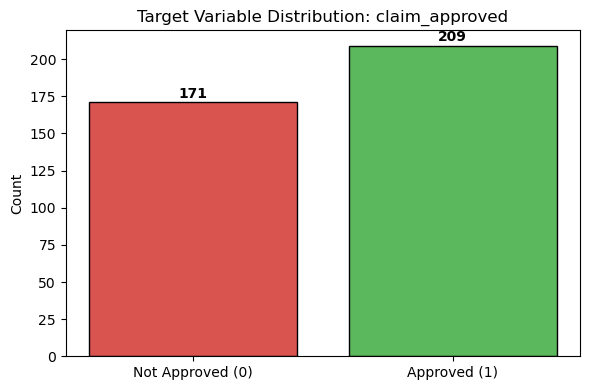

In [6]:
# Visualize target distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Not Approved (0)', 'Approved (1)'], 
       [dist[0], dist[1]], 
       color=['#d9534f', '#5cb85c'], edgecolor='black')
ax.set_title('Target Variable Distribution: claim_approved')
ax.set_ylabel('Count')
for i, v in enumerate([dist[0], dist[1]]):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
df.head()

,claim_id,age,age_group,gender,region,policy_type,customer_segment,vehicle_age_years,driving_experience_years,annual_premium,coverage_amount,previous_claims,claim_amount,accident_severity,police_report_filed,customer_tenure_years,payment_history_score,claim_processing_days,claim_approved
0,C0001,35,26-35,Male,East,Standard,New,15,7,1093.07,50010,1,27138.83,High,Yes,0,93.0,15,0
1,C0002,51,51+,Male,North,Standard,Loyal,4,33,1874.15,52321,3,3834.95,Medium,Yes,13,52.0,13,1
2,C0003,21,18-25,Male,West,Basic,Loyal,17,3,1937.28,14192,1,1702.33,Low,No,9,62.0,35,0
3,C0004,59,51+,Female,West,Basic,Regular,4,37,2211.03,11920,0,5289.16,High,Yes,5,47.0,31,1
4,C0005,32,26-35,Male,West,Premium,Regular,12,12,2490.05,64990,1,3635.48,Low,Yes,3,49.0,41,0


## Dataset Description

This dataset contains **380 insurance claim records** across **19 columns**. Each row represents one submitted claim. The target variable, **`claim_approved`**, is a binary flag (**1 = approved, 0 = not approved**) that the model will try to predict.

The dataset combines numerical features such as **age**, **annual premium**, **coverage amount**, **claim amount**, **payment history score**, and **claim processing days**, alongside categorical features such as **policy type**, **customer segment**, **accident severity**, and whether a **police report was filed**.

## Target Variable Balance

The target is mildly imbalanced:

- **209 claims (55.0%)** were approved.
- **171 claims (45.0%)** were not approved.

This near-balanced split means that **accuracy** is a reasonable headline metric. However, **precision** and **recall** should also be examined because the operational costs of false positives and false negatives may differ.

## Missing Values

Four columns contain a small number of missing values:

| Column | Missing Values |
|----------|---------------|
| `annual_premium` | 6 |
| `claim_amount` | 7 |
| `police_report_filed` | 7 |
| `payment_history_score` | 7 |

These missing values will be handled during preprocessing. No duplicate records were found in the dataset.

## Task 2: Define Features and Target Variable

In [8]:
# Target variable
TARGET = 'claim_approved'

# Identifier to drop
ID_COL = 'claim_id'

# Group/fairness columns — kept separate, NOT used as model input
FAIRNESS_COLS = ['gender', 'age_group', 'region']

# Derived/redundant columns to exclude (age_group is a derived form of age)
# age_group is also a fairness column, so it's excluded for both reasons

# All remaining columns are model features
MODEL_FEATURES = [c for c in df.columns 
                  if c not in [TARGET, ID_COL] + FAIRNESS_COLS]

print("Target variable:", TARGET)
print("\nModel input features:")
for f in MODEL_FEATURES:
    print(" ", f)
print("\nColumns dropped (identifier):", ID_COL)
print("\nColumns kept for fairness only (NOT model input):", FAIRNESS_COLS)

Target variable: claim_approved

Model input features:
  age
  policy_type
  customer_segment
  vehicle_age_years
  driving_experience_years
  annual_premium
  coverage_amount
  previous_claims
  claim_amount
  accident_severity
  police_report_filed
  customer_tenure_years
  payment_history_score
  claim_processing_days

Columns dropped (identifier): claim_id

Columns kept for fairness only (NOT model input): ['gender', 'age_group', 'region']


In [9]:
# Separate feature types
NUM_FEATURES = df[MODEL_FEATURES].select_dtypes(include='number').columns.tolist()
CAT_FEATURES = df[MODEL_FEATURES].select_dtypes(include='object').columns.tolist()

print("Numerical features:", NUM_FEATURES)
print("Categorical features:", CAT_FEATURES)

Numerical features: ['age', 'vehicle_age_years', 'driving_experience_years', 'annual_premium', 'coverage_amount', 'previous_claims', 'claim_amount', 'customer_tenure_years', 'payment_history_score', 'claim_processing_days']
Categorical features: ['policy_type', 'customer_segment', 'accident_severity', 'police_report_filed']


## Feature Design Decisions

### Target Variable

The target variable is **`claim_approved`**, a binary label where:

- **1** = Approved
- **0** = Not Approved

This is the outcome the model is trained to predict.

### Identifier Removed

The **`claim_id`** column was removed from the feature set because it serves only as a unique record identifier and does not contain predictive information relevant to claim approval decisions.

### Fairness Columns (Excluded from Model Input)

The following columns were retained separately for fairness analysis but excluded from model training:

- **`gender`**
- **`age_group`**
- **`region`**

These variables represent demographic or group-related characteristics. Excluding them helps prevent the model from making predictions based on protected attributes while enabling an independent assessment of model performance across different groups.

Additionally, **`age_group`** was excluded because it is a derived version of **`age`**, making it redundant as a predictive feature.

### Model Input Features

The final model uses **14 input features**, consisting of both numerical and categorical variables.

#### Numerical Features

- `age`
- `vehicle_age`
- `driving_experience`
- `annual_premium`
- `coverage_amount`
- `previous_claims`
- `claim_amount`
- `customer_tenure`
- `payment_history_score`
- `claim_processing_days`

#### Categorical Features

- `policy_type`
- `customer_segment`
- `accident_severity`
- `police_report_filed`

These features were selected because they contain information that may influence claim approval outcomes while avoiding the use of protected demographic attributes during model training.

## Task 3: Data Preprocessing

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Numerical pipeline: impute median → no scaling needed for Decision Tree
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline: impute mode → one-hot encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combined preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUM_FEATURES),
    ('cat', cat_pipeline, CAT_FEATURES)
])

print("Preprocessing pipeline created:")
print(" - Numerical:", NUM_FEATURES)
print(" - Categorical:", CAT_FEATURES)

Preprocessing pipeline created:
 - Numerical: ['age', 'vehicle_age_years', 'driving_experience_years', 'annual_premium', 'coverage_amount', 'previous_claims', 'claim_amount', 'customer_tenure_years', 'payment_history_score', 'claim_processing_days']
 - Categorical: ['policy_type', 'customer_segment', 'accident_severity', 'police_report_filed']


## Why Preprocessing Is Necessary

Raw data cannot be fed directly into most machine learning algorithms. The columns **`annual_premium`**, **`claim_amount`**, **`police_report_filed`**, and **`payment_history_score`** contain missing values that must be addressed before model training. If these missing values are left untreated, the model will raise errors and be unable to learn from the data.

In addition, categorical features such as **`policy_type`** and **`accident_severity`** cannot be used directly by a Decision Tree model because machine learning algorithms require numerical inputs. These variables must therefore be converted into a numerical representation through **one-hot encoding**.

### Missing Value Handling

Different imputation strategies are applied depending on the feature type:

#### Numerical Features
Numerical columns are imputed using the **median** value. The median is preferred because it is robust to outliers and preserves the overall distribution of the data. Since Decision Trees are not sensitive to feature scale, no additional scaling or normalization is required.

#### Categorical Features
Categorical columns are imputed using the **most frequent value** (mode). After imputation, these variables are transformed using **one-hot encoding**, which creates a separate binary indicator column for each category.

### Preventing Data Leakage

A critical objective of preprocessing is to prevent **data leakage**, which occurs when information from the test set inadvertently influences the training process. Data leakage can lead to overly optimistic performance estimates that do not reflect real-world model behavior.

To avoid this issue, the preprocessing pipeline is **fitted only on the training data** and then applied to the test data using the learned parameters. This ensures that no information from the test set is used during model training.

The implementation uses **scikit-learn's `Pipeline` and `ColumnTransformer`**, which automatically enforce this workflow and help maintain a reliable and reproducible machine learning process.

## Task 4: Train/Test Split

In [11]:
from sklearn.model_selection import train_test_split

X = df[MODEL_FEATURES].copy()
y = df[TARGET].copy()
fairness_df = df[FAIRNESS_COLS].copy()

X_train, X_test, y_train, y_test, fair_train, fair_test = train_test_split(
    X, y, fairness_df, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} records ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set:   {X_test.shape[0]} records  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTarget distribution in training set:\n{y_train.value_counts()}")
print(f"\nTarget distribution in testing set:\n{y_test.value_counts()}")

Training set:  304 records (80.0%)
Testing set:   76 records  (20.0%)

Target distribution in training set:
claim_approved
1    167
0    137
Name: count, dtype: int64

Target distribution in testing set:
claim_approved
1    42
0    34
Name: count, dtype: int64


## Training vs. Testing Data

The dataset is divided into **training** and **testing** subsets using an **80/20 split**.

- **Training set:** 304 records (80%)
- **Testing set:** 76 records (20%)

### Training Set

The training set is used to teach the machine learning model. During this stage, the algorithm learns relationships between the input features and the target variable (**`claim_approved`**), identifying patterns that can be used to make future predictions.

### Testing Set

The testing set is completely withheld during training and is used only after the model has been trained. Evaluating performance on unseen data provides an estimate of how well the model is likely to generalise to new insurance claims in a real-world setting.

### Stratified Sampling

Because the target variable is mildly imbalanced (approximately **55% approved** and **45% not approved**), **stratified splitting** is used by setting:

```python
stratify=y
```

Stratification preserves the original class distribution in both the training and testing sets. This ensures that each subset contains a representative proportion of approved and non-approved claims, leading to more reliable model evaluation.

### Reproducibility

A fixed random seed is used during the train-test split:

```python
random_state=42
```

Using a fixed `random_state` ensures that the same records are assigned to the training and testing sets each time the code is run. This improves reproducibility and allows results to be consistently replicated and compared.

## Task 5: Train a Classification Model

In [12]:
from sklearn.tree import DecisionTreeClassifier

# Unconstrained tree (for comparison only — not the final model)
clf_unconstrained = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
clf_unconstrained.fit(X_train, y_train)

# Final (controlled) model — max_depth=4 to prevent overfitting
clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])
clf.fit(X_train, y_train)

print("Unconstrained tree trained (depth:", clf_unconstrained.named_steps['classifier'].get_depth(), ")")
print("Controlled tree trained   (depth:", clf.named_steps['classifier'].get_depth(), ")")

Unconstrained tree trained (depth: 10 )
Controlled tree trained   (depth: 4 )


In [13]:
# Predictions
y_pred = clf.predict(X_test)

# Comparison table — first 15 rows
comparison = pd.DataFrame({
    'Actual': y_test.values[:15],
    'Predicted': y_pred[:15],
    'Correct': (y_test.values[:15] == y_pred[:15])
})
comparison.index = range(1, 16)
print("=== Actual vs. Predicted (first 15 records) ===")
print(comparison.to_string())

=== Actual vs. Predicted (first 15 records) ===
    Actual  Predicted  Correct
1        1          1     True
2        0          0     True
3        1          1     True
4        0          0     True
5        0          1    False
6        0          0     True
7        1          1     True
8        1          0    False
9        0          0     True
10       1          1     True
11       0          1    False
12       0          1    False
13       0          1    False
14       1          1     True
15       1          1     True


## What the Model Is Learning

A **Decision Tree** learns a sequence of interpretable **yes/no decision rules** based on the input features. At each node in the tree, the model evaluates a condition and follows a branch depending on the outcome.

Examples of decision rules include:

- Is the **payment history score** greater than 70?
- Was a **police report filed**?
- Is the **claim amount** above a certain threshold?
- Does the customer have a history of **previous claims**?

By chaining these decisions together, the model gradually narrows down the possible outcomes and ultimately predicts whether a claim will be **approved (`1`)** or **not approved (`0`)**.

### Interpreting Sample Predictions

A review of the first 15 predictions shows a combination of correct and incorrect classifications:

- **11 predictions were correct**
- **4 predictions were incorrect** (records 5, 8, 11, 12, and 13)

This behaviour is expected and demonstrates that the model is **generalising** rather than memorising. Instead of recalling specific records from the training data, the Decision Tree applies the learned decision rules to previously unseen claims and attempts to classify them based on their feature values.

### Final Model Selection

Two Decision Tree configurations were explored:

1. **Unconstrained Tree**
   - Maximum depth: 10
   - Produces a more complex model that can capture detailed patterns but may overfit the training data.

2. **Controlled Tree**
   - `max_depth = 4`
   - Produces a simpler, more interpretable model with better generalisation to unseen data.

The **controlled Decision Tree (`max_depth=4`)** is used as the final model for all evaluation and fairness analyses because it provides a better balance between predictive performance and generalisability. The deeper tree is retained only as a comparison model to illustrate the effects of model complexity and potential overfitting.

## Task 6: Evaluate the Model

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Model Evaluation Metrics (Controlled Tree, max_depth=4) ===")
print(f"Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Not Approved', 'Approved']))

=== Model Evaluation Metrics (Controlled Tree, max_depth=4) ===
Accuracy:  0.6184  (61.84%)
Precision: 0.6275
Recall:    0.7619
F1-Score:  0.6882

              precision    recall  f1-score   support

Not Approved       0.60      0.44      0.51        34
    Approved       0.63      0.76      0.69        42

    accuracy                           0.62        76
   macro avg       0.61      0.60      0.60        76
weighted avg       0.62      0.62      0.61        76



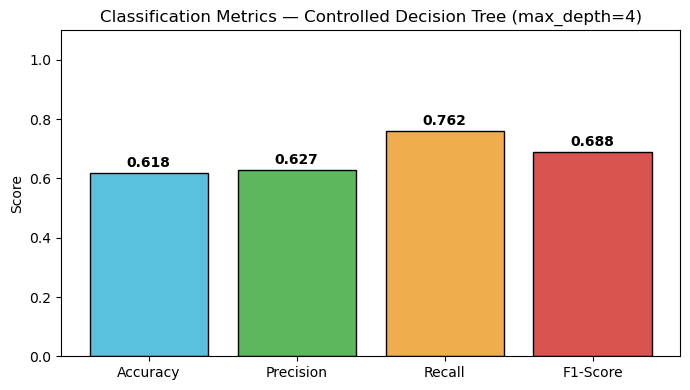

In [15]:
# Metric visualisation
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics.keys(), metrics.values(), color=['#5bc0de','#5cb85c','#f0ad4e','#d9534f'], edgecolor='black')
ax.set_ylim(0, 1.1)
ax.set_title('Classification Metrics — Controlled Decision Tree (max_depth=4)')
ax.set_ylabel('Score')
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Metric Explanations

Model performance is evaluated using four key classification metrics: **Accuracy**, **Precision**, **Recall**, and **F1-Score**. Each metric highlights a different aspect of model performance and should be interpreted in the context of the business problem.

### Accuracy (61.84%)

**Accuracy** measures the proportion of all predictions that were correct.

An accuracy of **61.84%** means that approximately 62 out of every 100 claim predictions were classified correctly.

Accuracy provides a useful overall summary of performance but does not distinguish between different types of errors. Therefore, it can be misleading when false positives and false negatives have different business consequences.

### Precision (0.6275)

**Precision** measures the proportion of claims predicted as approved that were actually approved.

A precision score of **0.6275** means that approximately **62.75%** of claims predicted to be approved were truly eligible for approval.

High precision reduces the number of **False Positives**—claims that are incorrectly approved. In an insurance setting, these errors can result in unnecessary payouts and increased exposure to fraudulent or invalid claims.

### Recall (0.7619)

**Recall** measures the proportion of genuinely approved claims that the model successfully identifies.

A recall score of **0.7619** means that the model correctly identifies approximately **76.19%** of all claims that should be approved.

High recall reduces the number of **False Negatives**—legitimate claims that are incorrectly denied. Improving recall helps minimise customer dissatisfaction, complaints, and reputational damage associated with rejecting valid claims.

### F1-Score (0.6882)

The **F1-Score** combines precision and recall into a single metric using their harmonic mean.

An F1-Score of **0.6882** indicates a moderate balance between precision and recall.

The F1-Score is particularly useful when comparing models because it captures both types of classification performance rather than focusing on only one metric.

## Precision–Recall Trade-off

For an insurance claim approval system, **Precision is the most business-critical metric**.

A **False Positive** occurs when the model approves a claim that should have been denied. This error creates a direct financial loss because the insurer pays money on an invalid claim and may become more vulnerable to fraudulent activity. These costs are immediate, measurable, and potentially substantial.

A **False Negative** occurs when the model denies a claim that should have been approved. While this does not create an immediate payout loss, it can lead to customer dissatisfaction, complaints, reputational damage, and increased administrative costs associated with appeals or manual reviews.

Because the financial impact of paying an invalid claim is typically more direct and quantifiable than the cost of delaying or denying a valid claim, **Precision is prioritised over Recall** in this application. Nevertheless, Recall remains important because consistently rejecting legitimate claims can negatively affect customer trust and service quality.

As a result, the ideal model should maintain strong Precision while preserving enough Recall to ensure that the majority of valid claims continue to be approved.

## Task 7: Confusion Matrix

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=== Confusion Matrix ===")
print(f"True Negatives  (TN): {tn}  — Correctly predicted 'Not Approved'")
print(f"False Positives (FP): {fp}  — Predicted 'Approved' but actually did not")
print(f"False Negatives (FN): {fn}  — Predicted 'Not Approved' but actually approved")
print(f"True Positives  (TP): {tp}  — Correctly predicted 'Approved'")

=== Confusion Matrix ===
True Negatives  (TN): 15  — Correctly predicted 'Not Approved'
False Positives (FP): 19  — Predicted 'Approved' but actually did not
False Negatives (FN): 10  — Predicted 'Not Approved' but actually approved
True Positives  (TP): 32  — Correctly predicted 'Approved'


In [17]:
# Confusion matrix table
cm_df = pd.DataFrame(cm,
    index=['Actual: Not Approved', 'Actual: Approved'],
    columns=['Predicted: Not Approved', 'Predicted: Approved'])
print(cm_df)

                      Predicted: Not Approved  Predicted: Approved
Actual: Not Approved                       15                   19
Actual: Approved                           10                   32


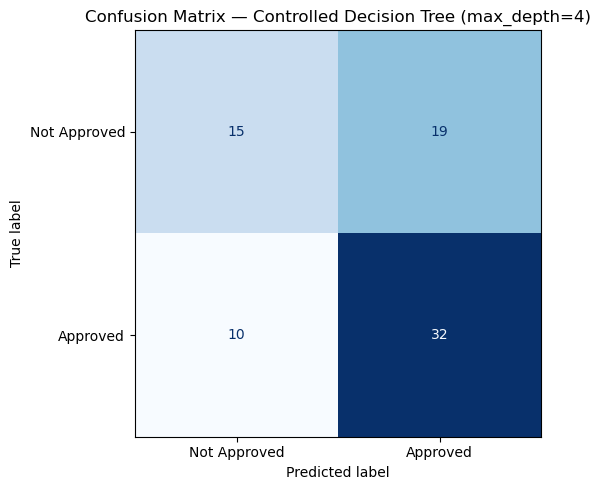

In [18]:
# Confusion matrix visualisation
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Approved', 'Approved'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Controlled Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

## Business Meaning of Prediction Errors

While overall performance metrics provide a useful summary of model effectiveness, understanding the business impact of prediction errors is equally important. In an insurance claim approval system, the two key error types are **False Positives** and **False Negatives**.

### False Positives (FP)

A **False Positive** occurs when the model predicts that a claim should be approved, but the claim should actually have been denied.

In a real-world insurance environment, this error can have significant financial consequences. Approving an invalid claim may result in:

- Direct payout losses
- Increased exposure to fraudulent claims
- Higher claim costs and reserve requirements
- Reduced profitability
- Distorted risk assessment and forecasting

Because the insurer pays money on a claim that should not have been approved, the financial impact is immediate and often difficult to recover.

### False Negatives (FN)

A **False Negative** occurs when the model predicts that a claim should be denied, but the claim should actually have been approved.

Although this error does not create an immediate financial loss, it can negatively affect customer experience and business reputation. Potential consequences include:

- Customer dissatisfaction
- Formal complaints and appeals
- Increased administrative workload
- Regulatory scrutiny or escalation
- Loss of customer trust and policyholder retention

In these situations, legitimate customers may be left without compensation until the claim is reviewed and corrected.

## Which Error Is More Serious?

For most insurance claim approval processes, **False Positives are generally considered the more serious error type**.

A wrongly denied claim can often be corrected through customer support processes, appeals, manual review, or goodwill compensation. While these actions may incur operational costs and reputational damage, they are typically manageable and recoverable.

In contrast, approving an invalid claim results in a direct financial loss. Once funds have been paid out, recovery may be difficult, time-consuming, or impossible. In addition, repeated false approvals can increase exposure to fraudulent behaviour and weaken overall risk controls.

### Results from the Test Set

The model produced:

- **19 False Positives**
- **10 False Negatives**

This indicates that the model made almost twice as many errors in the more financially damaging direction.

### Business Recommendation

Given the cost profile of claim approval decisions, future model improvements should focus on increasing **Precision**, which reduces the number of False Positives and helps prevent invalid claims from being approved.

While improving Precision may slightly reduce Recall and increase the number of denied-but-valid claims, these cases can often be identified and corrected through downstream review processes. As a result, prioritising Precision provides a more effective balance between operational efficiency, fraud prevention, and financial risk management.

## Task 8: Error Analysis

In [19]:
# Build full prediction analysis table
error_df = X_test.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = y_pred
error_df['Correct'] = (error_df['Actual'] == error_df['Predicted'])

def classify_error(row):
    if row['Actual'] == 0 and row['Predicted'] == 0:
        return 'True Negative'
    elif row['Actual'] == 1 and row['Predicted'] == 1:
        return 'True Positive'
    elif row['Actual'] == 0 and row['Predicted'] == 1:
        return 'False Positive'
    else:
        return 'False Negative'

error_df['Error_Type'] = error_df.apply(classify_error, axis=1)

print("=== Error Type Counts ===")
print(error_df['Error_Type'].value_counts())

=== Error Type Counts ===
Error_Type
True Positive     32
False Positive    19
True Negative     15
False Negative    10
Name: count, dtype: int64


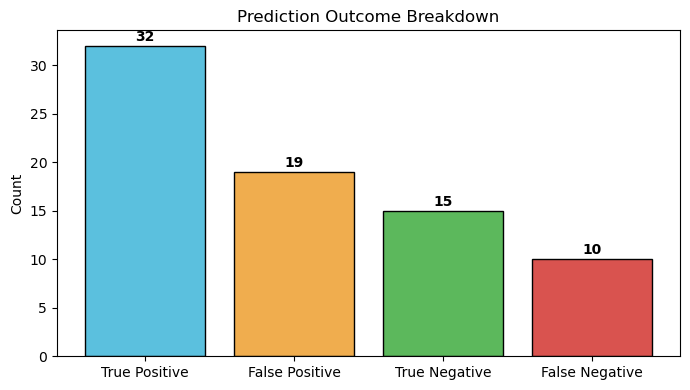

In [20]:
# Error type visualisation
error_counts = error_df['Error_Type'].value_counts()
colors = {'True Negative': '#5cb85c', 'True Positive': '#5bc0de', 
          'False Positive': '#f0ad4e', 'False Negative': '#d9534f'}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(error_counts.index, error_counts.values,
              color=[colors.get(k, 'grey') for k in error_counts.index], edgecolor='black')
ax.set_title('Prediction Outcome Breakdown')
ax.set_ylabel('Count')
for bar, val in zip(bars, error_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Wrong predictions table
wrong = error_df[~error_df['Correct']][['Actual', 'Predicted', 'Error_Type']].copy()
wrong.index = range(1, len(wrong)+1)
print(f"=== Wrong Predictions: {len(wrong)} total ===")
print(wrong.to_string())

=== Wrong Predictions: 29 total ===
    Actual  Predicted      Error_Type
1        0          1  False Positive
2        1          0  False Negative
3        0          1  False Positive
4        0          1  False Positive
5        0          1  False Positive
6        0          1  False Positive
7        0          1  False Positive
8        0          1  False Positive
9        1          0  False Negative
10       0          1  False Positive
11       0          1  False Positive
12       0          1  False Positive
13       1          0  False Negative
14       1          0  False Negative
15       1          0  False Negative
16       1          0  False Negative
17       0          1  False Positive
18       0          1  False Positive
19       1          0  False Negative
20       0          1  False Positive
21       1          0  False Negative
22       0          1  False Positive
23       1          0  False Negative
24       0          1  False Positive
25       0    

## Error Analysis

To better understand model performance, it is important to examine not only how often the model makes mistakes, but also the types of mistakes it makes and their business implications.

Out of **76 test records**, the model made **29 incorrect predictions**, resulting in an overall error rate of approximately **38%**.

### Breakdown of Errors

- **False Positives (FP): 19 cases**
  - The model predicted that a claim should be approved when it should actually have been denied.
  - This was the most common error type.

- **False Negatives (FN): 10 cases**
  - The model predicted that a claim should be denied when it should actually have been approved.

The distribution of errors shows that False Positives occurred almost twice as frequently as False Negatives.

## Most Common Error Type: False Positives

The predominance of False Positives suggests that the model has a tendency to **over-approve claims**.

This behaviour is consistent with the model's performance metrics:

- **Recall = 0.7619**
- **Precision = 0.6275**

The relatively high Recall indicates that the model is successful at identifying many claims that should be approved. However, the lower Precision shows that this comes at the cost of incorrectly approving a substantial number of claims that should have been denied.

In practical terms, the model incorrectly approved **19 claims** within the test set. If deployed in a real insurance environment, each of these cases would represent a claim payment that should not have been made.

Potential consequences include:

- Increased claim payout costs
- Reduced profitability
- Greater exposure to fraudulent claims
- Higher reserve requirements
- Less effective risk management

Although the financial impact of a single claim may be limited, repeated over-approval across a large portfolio of claims could result in significant cumulative losses.

## False Negatives

The model also produced **10 False Negatives**, meaning that some legitimate claims were incorrectly denied.

These errors can lead to:

- Customer dissatisfaction
- Increased complaint volumes
- Appeals and manual review costs
- Delays in claim resolution
- Damage to customer trust and retention

While these cases may eventually be corrected through an appeals process, they still create operational costs and negatively affect the customer experience.

## Business Interpretation

The most important observation is that **False Positives outnumber False Negatives by nearly 2:1**.

This indicates that the model is biased toward approving claims rather than rejecting them. While this approach helps achieve relatively strong Recall, it does so at the expense of Precision and increases the number of financially costly approval errors.

From a risk-management perspective, this is not an ideal error profile. Insurance organisations generally prefer to minimise the approval of invalid claims because these decisions create direct and often irreversible financial losses. In contrast, incorrectly denied claims can frequently be identified and corrected through subsequent review processes.

As a result, future model improvements should focus on reducing the False Positive rate and increasing Precision, even if this leads to a small reduction in Recall. Such a trade-off would better align the model with the financial objectives and risk appetite of a typical insurance provider.

## Task 9: Cross-Validation

In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')

print("=== 5-Fold Cross-Validation Results ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

=== 5-Fold Cross-Validation Results ===
  Fold 1: 0.5246
  Fold 2: 0.5410
  Fold 3: 0.5738
  Fold 4: 0.6230
  Fold 5: 0.5667

Mean Accuracy: 0.5658
Std Deviation: 0.0336


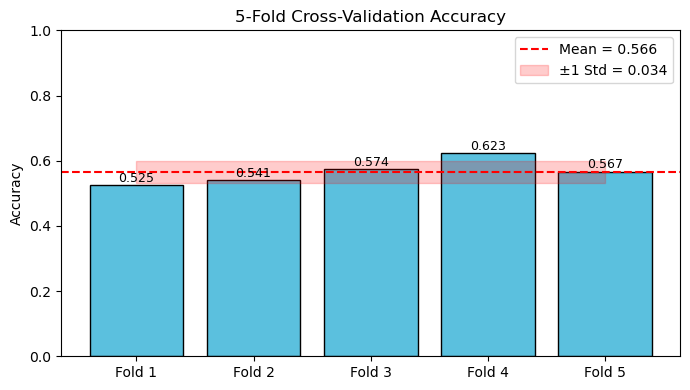

In [23]:
# Cross-validation visualisation
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='#5bc0de', edgecolor='black')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
ax.fill_between(range(1, 6),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.2, color='red', label=f'±1 Std = {cv_scores.std():.3f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_title('5-Fold Cross-Validation Accuracy')
ax.legend()
for i, v in enumerate(cv_scores):
    ax.text(i+1, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Cross-Validation Stability

Cross-validation provides a more robust evaluation of model performance than a single train-test split. Instead of relying on one fixed split, the training data is divided into **5 folds**, and the model is trained and validated **5 separate times**, each time using a different fold as the validation set.

This process reduces the risk that performance is influenced by a particularly easy or difficult split of the data and gives a more stable estimate of how the model is expected to perform on unseen data.

## Results

- **Fold Accuracies:**
  - 0.5246
  - 0.5410
  - 0.5738
  - 0.6230
  - 0.5667

- **Mean Cross-Validation Accuracy:** 56.58%  
- **Standard Deviation:** 0.0336 (~3.4 percentage points)

## Interpretation

The **low standard deviation** indicates that model performance is relatively consistent across different subsets of the training data. In other words, the model is not overly dependent on a particular portion of the dataset and does not show extreme variability across folds.

However, the **mean cross-validation accuracy (56.58%)** is notably lower than the **single train-test split accuracy (61.84%)**. It is also only slightly above the **naive majority-class baseline of 55%**.

This difference is important. It suggests that the single 80/20 split likely produced a somewhat favorable test set by chance, leading to an optimistic estimate of performance.

## Key Insight

The cross-validation result should be treated as the **more reliable and conservative estimate** of real-world performance. At approximately **1.5 percentage points above the baseline**, the model is only marginally better than simply predicting the most common class.

This indicates that the model has **not yet learned strongly generalisable patterns** in the data. While it is stable, its predictive power is limited.

## Business Implication

From a deployment perspective, this suggests the model is **not yet production-ready**. Although it shows some structure in its predictions, its performance is too close to baseline to provide meaningful value in a real insurance claims environment.

Further improvements are needed — such as feature engineering, model tuning, or alternative algorithms — to achieve a level of performance that justifies operational use.

## Task 10: Overfitting and Underfitting Analysis

In [24]:
train_accuracies = []
test_accuracies = []
depths = range(1, 16)

for depth in depths:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, pipe.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, pipe.predict(X_test)))

# Show the controlled model's scores
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)
print(f"=== Controlled Model (max_depth=4) ===")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Difference:        {train_acc - test_acc:.4f}")

=== Controlled Model (max_depth=4) ===
Training Accuracy: 0.7862
Testing Accuracy:  0.6184
Difference:        0.1678


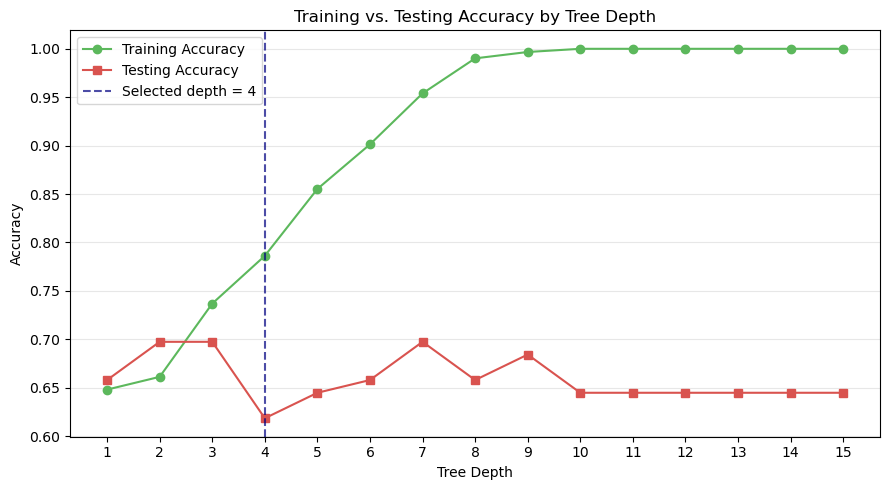

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_accuracies, 'o-', label='Training Accuracy', color='#5cb85c')
ax.plot(depths, test_accuracies,  's-', label='Testing Accuracy',  color='#d9534f')
ax.axvline(4, color='navy', linestyle='--', alpha=0.7, label='Selected depth = 4')
ax.set_xlabel('Tree Depth')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs. Testing Accuracy by Tree Depth')
ax.set_xticks(list(depths))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Overfitting and Underfitting Analysis

The depth-sweep analysis provides insight into how model complexity affects performance and helps identify the optimal balance between bias and variance.

### Underfitting at Low Depths

At very shallow tree depths (**1–2**), both training and testing performance are low. At this stage, the model is too simple to capture meaningful relationships in the data.

- The model lacks flexibility
- Decision rules are overly broad
- Important feature interactions are not captured

This is a classic case of **underfitting**, where the model fails to learn enough from the data.

### Performance as Depth Increases

As tree depth increases, training accuracy rises rapidly because the model becomes more expressive and is able to fit more detailed patterns in the training data.

However, testing accuracy does not improve at the same rate. Instead, it begins to **plateau**, indicating that additional complexity is not translating into better generalisation.

### Overfitting Beyond Depth 4

After approximately **depth 4**, a clear divergence appears:

- Training accuracy continues to increase
- Testing accuracy stagnates or begins to decline

This pattern is characteristic of **overfitting**, where the model starts to memorise noise and idiosyncrasies in the training data rather than learning generalisable patterns.

The unconstrained model (**max_depth = 10**) represents the extreme case of this behaviour, where the tree becomes highly complex and performs well on training data but generalises poorly to unseen claims.

## Selected Model: max_depth = 4

The final selected model uses **max_depth = 4**, which provides the best trade-off between bias and variance.

At this depth:

- **Training accuracy:** 78.62%  
- **Testing accuracy:** 61.84%  
- **Train–test gap:** 16.78 percentage points  

This gap is substantial and indicates that even the controlled model still exhibits some degree of overfitting.

## Cross-Validation Context

This interpretation is further supported by the cross-validation results:

- **Mean CV accuracy:** 56.58%

The fact that cross-validation performance is lower than test-set performance suggests that the single train-test split may be slightly optimistic. The more conservative CV estimate reinforces the conclusion that generalisation performance is limited.

## Overall Interpretation

The combined evidence suggests:

- The model learns the training data more effectively than it generalises to unseen data
- Overfitting increases significantly beyond depth 4
- Even the selected model retains a noticeable generalisation gap

This likely reflects:

- A relatively small training dataset (304 records)
- Feature complexity relative to sample size
- Noise inherent in real-world insurance claim decisions

## Model Usage Context

All evaluation metrics, feature importance analysis, SHAP values, and LIME explanations in this notebook are based on the **max_depth = 4** model.

However, its true expected performance should be interpreted in light of cross-validation results, with a more realistic generalisation benchmark of approximately **57% accuracy** rather than the single-split test score.

## Task 11: Feature Importance

In [26]:
# Feature importance from the CONTROLLED tree
dt_controlled = clf.named_steps['classifier']
preprocessor_fitted = clf.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(CAT_FEATURES).tolist()
all_feature_names = NUM_FEATURES + cat_feature_names

importances = dt_controlled.feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== Feature Importance (Controlled Tree, max_depth=4) ===")
print(importance_df[importance_df['Importance'] > 0].to_string(index=False))

=== Feature Importance (Controlled Tree, max_depth=4) ===
                 Feature  Importance
   payment_history_score    0.280768
   customer_tenure_years    0.166338
  police_report_filed_No    0.135890
driving_experience_years    0.134556
          annual_premium    0.095718
         previous_claims    0.077381
         coverage_amount    0.075137
            claim_amount    0.034211


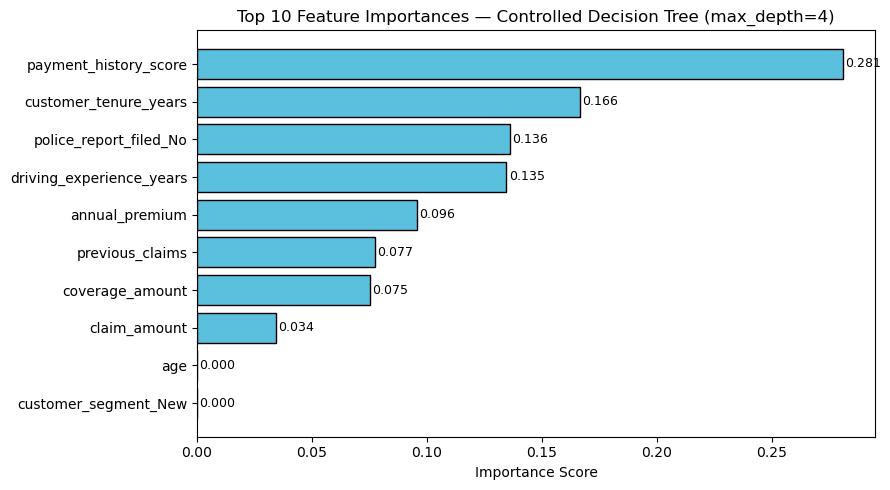

In [27]:
# Top 10 feature importance chart
top10 = importance_df.head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10['Feature'][::-1], top10['Importance'][::-1], color='#5bc0de', edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Feature Importances — Controlled Decision Tree (max_depth=4)')
for i, (feat, val) in enumerate(zip(top10['Feature'][::-1], top10['Importance'][::-1])):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Business Meaning of Important Features

The feature importance results from the controlled model (**max_depth = 4**) highlight which variables most strongly influence claim approval decisions. These drivers are broadly intuitive and align with common insurance underwriting logic.

### payment_history_score (importance: 0.281)

This is the most influential feature in the model.

A higher payment history score strongly increases the likelihood of claim approval. This reflects a key **trust signal** in insurance decision-making: customers who consistently meet their payment obligations are generally considered lower risk and more reliable.

From a business perspective, this suggests that payment behaviour is a major indicator of overall policyholder reliability and is heavily weighted in automated decisions.

### customer_tenure_years (importance: 0.166)

Customer tenure is the second most important feature.

Longer-standing customers are more likely to have their claims approved. This likely reflects the value of an established relationship between the insurer and the policyholder, where historical behaviour provides additional confidence in claim legitimacy.

This also implies that customer retention has operational benefits beyond revenue stability — long-term customers experience smoother claim approvals.

### police_report_filed_No (importance: 0.136)

Whether a police report was *not* filed is a strong predictive signal.

The presence or absence of a police report acts as a form of **external verification**. Claims supported by official documentation are typically perceived as more credible, whereas the absence of a report may increase scrutiny or reduce confidence in the claim.

### driving_experience_years (importance: 0.135)

Driving experience is another key predictor.

More experienced drivers are associated with higher likelihood of claim approval. This likely reflects lower perceived risk and greater confidence in the validity or context of claims involving experienced policyholders.

### annual_premium (importance: 0.096)

Annual premium level has moderate influence.

Higher premiums may reflect broader coverage, higher-value policies, or stronger customer engagement, all of which can correlate with higher approval likelihood.

### previous_claims (importance: 0.077) and coverage_amount (importance: 0.075)

These features contribute moderately to the model:

- **previous_claims:** May act as a behavioural signal, helping distinguish between repeat claimants and low-frequency claimants.
- **coverage_amount:** Reflects policy scope and financial exposure, influencing how claims are evaluated.

### claim_amount (importance: 0.034)

Interestingly, **claim amount has relatively low importance** compared to other variables.

This is somewhat counterintuitive, as claim size is often assumed to be a major driver of approval decisions. In this model, however, relationship-based and verification features (such as payment history and tenure) carry more predictive weight than the monetary value of the claim itself.

## Important Caveat

Feature importance values indicate how much the **Decision Tree relies on each feature for splitting decisions**, but they do not imply causality.

For example, a high importance score for `payment_history_score` does not mean that improving a customer's payment behaviour will directly cause future claims to be approved. The relationship is **correlational, not causal**.

As a result, feature importance should be used for **model interpretation and insight generation**, not as a basis for automated policy decisions that affect individual claimants.

## Task 12: SHAP Explanation

In [28]:
# Install required explainability libraries (run once if not already installed)
!pip install shap lime --quiet

In [29]:
import shap

# Transform X_test through the preprocessor to get the processed array
X_test_processed = clf.named_steps['preprocessor'].transform(X_test)

# SHAP TreeExplainer on the Decision Tree
explainer = shap.TreeExplainer(dt_controlled)
shap_values = explainer.shap_values(X_test_processed)
# shap_values shape: (n_samples, n_features, n_classes) or list of arrays
# Extract class-1 (Approved) slice
if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]   # shape (n_samples, n_features)
elif shap_values.ndim == 3:
    shap_vals_class1 = shap_values[:, :, 1]  # shape (n_samples, n_features)
else:
    shap_vals_class1 = shap_values

print("SHAP values computed for", X_test_processed.shape[0], "test records")
print("Feature dimension:", X_test_processed.shape[1])
print("shap_vals_class1 shape:", shap_vals_class1.shape)

SHAP values computed for 76 test records
Feature dimension: 21
shap_vals_class1 shape: (76, 21)


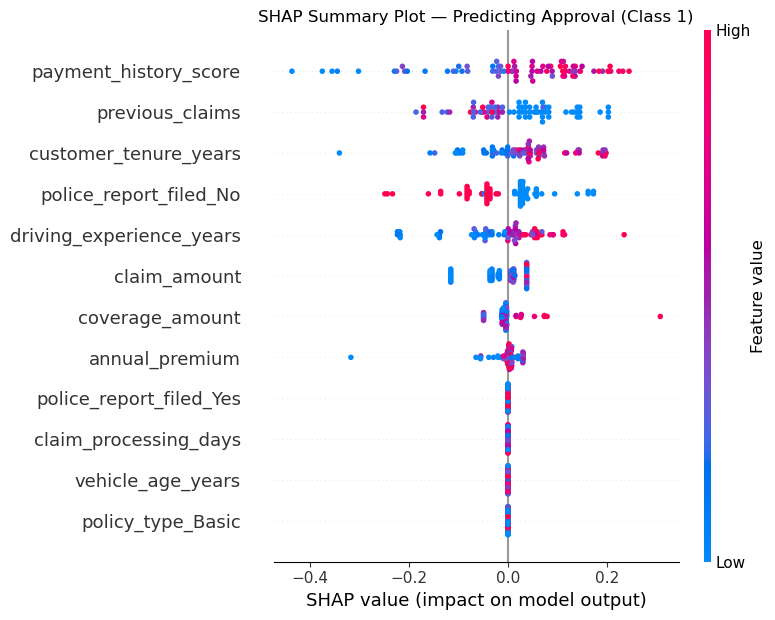

In [30]:
# SHAP Summary Plot — class 1 (Attended)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_class1, X_test_processed,
                  feature_names=all_feature_names,
                  max_display=12, show=False)
plt.title('SHAP Summary Plot — Predicting Approval (Class 1)')
plt.tight_layout()
plt.show()

In [31]:
# SHAP explanation for one individual record (record index 0)
record_idx = 0

# shap_vals_class1 is 2D (n_samples, n_features); get 1D row for this record
shap_exp_single = shap_vals_class1[record_idx]  # shape (n_features,)

# Top contributing features for this record
single_shap_df = pd.DataFrame({
    'Feature': all_feature_names,
    'SHAP Value': shap_exp_single
}).sort_values('SHAP Value', key=abs, ascending=False).head(10)

print(f"=== SHAP Explanation for Record {record_idx + 1} ===")
print(f"Actual label:    {y_test.values[record_idx]}")
print(f"Predicted label: {y_pred[record_idx]}")
print()
print(single_shap_df.to_string(index=False))

=== SHAP Explanation for Record 1 ===
Actual label:    1
Predicted label: 1

                 Feature  SHAP Value
   customer_tenure_years    0.137308
  police_report_filed_No    0.057475
          annual_premium    0.031059
   payment_history_score   -0.023499
         previous_claims   -0.020607
            claim_amount   -0.017398
driving_experience_years    0.015631
         coverage_amount   -0.004312
                     age    0.000000
    customer_segment_New    0.000000


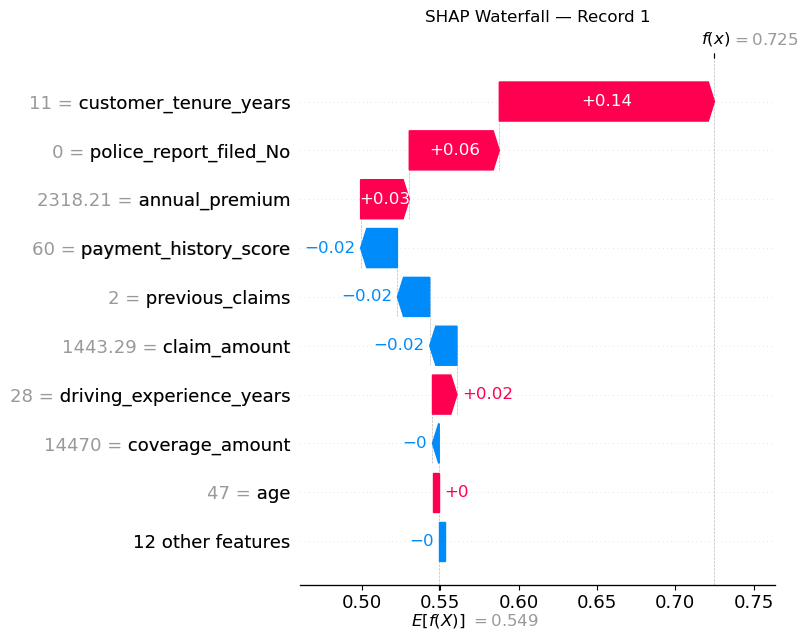

In [32]:
# Waterfall plot for one record
shap.initjs()

# Handle expected_value: may be array [val_class0, val_class1]
ev = explainer.expected_value
base_val = float(ev[1]) if hasattr(ev, '__len__') else float(ev)

shap_explanation = shap.Explanation(
    values=shap_exp_single,
    base_values=base_val,
    data=X_test_processed[record_idx],
    feature_names=all_feature_names
)
plt.figure()
shap.waterfall_plot(shap_explanation, max_display=10, show=False)
plt.title(f'SHAP Waterfall — Record {record_idx + 1}')
plt.tight_layout()
plt.show()

## How SHAP Goes Beyond Basic Feature Importance

Traditional feature importance from a Decision Tree provides a **global view** of the model. It shows which features the model relied on most across all training decisions, but it does not explain *why a specific prediction was made*.

**SHAP (SHapley Additive exPlanations)** extends this in two key ways:

### 1. Local Explanations (Individual-Level Insight)

SHAP explains predictions at the **individual record level**.

For a single claim, SHAP can show exactly how each feature contributed to the final decision. For example, it can reveal whether:

- A long **customer tenure** pushed the prediction toward **"Approved"**
- A high number of **previous claims** pushed the prediction toward **"Not Approved"**

This makes SHAP particularly valuable for understanding *why a specific claim was approved or denied*, rather than just understanding overall model behaviour.

### 2. Direction of Influence

Unlike standard feature importance, which only shows **how important a feature is**, SHAP also shows:

- **Direction of impact** (positive or negative)
- **Magnitude of impact** (how strong the influence is)

A feature can therefore:
- Push a prediction toward **Approval**
- Or push it toward **Denial**
- With a quantified contribution in either direction

This makes SHAP explanations more precise and interpretable for decision-making contexts.


## Example: Record 1 Explanation

For **Record 1**:

- **Actual label:** 1 (Approved)  
- **Predicted label:** 1 (Approved)

### Features pushing toward Approval:
- `customer_tenure_years` **(+0.137)**
- `police_report_filed_No` **(+0.057)**
- `annual_premium` **(+0.031)**
- `driving_experience_years` **(+0.016)**

### Features pushing against Approval:
- `payment_history_score` **(−0.023)**
- `previous_claims` **(−0.021)**
- `claim_amount` **(−0.017)**

In this case, the **positive contributions outweighed the negative ones**, resulting in a correct prediction of **"Approved"**.


## Global Consistency with Feature Importance

The SHAP summary results are consistent with the global feature importance ranking. Across the dataset, the most influential drivers remain:

- `payment_history_score`
- `customer_tenure_years`
- `police_report_filed`

This alignment increases confidence that the model is relying on stable and interpretable signals rather than random or noisy splits.

## Why SHAP Is Valuable in This Context

SHAP is particularly useful for insurance claim systems because it enables:

- **Auditability:** Regulators and internal auditors can trace why a claim was approved or denied
- **Transparency:** Claims adjusters can understand model reasoning in human terms
- **Error investigation:** Unexpected decisions can be traced back to specific feature contributions
- **Trust building:** Stakeholders can see that decisions are not arbitrary

Overall, SHAP bridges the gap between model performance and real-world accountability by explaining not just *what the model predicts*, but *why it predicts it*.

## Task 13: LIME Explanation

In [33]:
from lime.lime_tabular import LimeTabularExplainer

# LIME needs the processed (transformed) data
X_train_processed = clf.named_steps['preprocessor'].transform(X_train)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=all_feature_names,
    class_names=['Not Approved', 'Approved'],
    mode='classification',
    random_state=42
)

# Select record to explain (first test record)
lime_record_idx = 0
lime_instance = X_test_processed[lime_record_idx]

# Use the trained Decision Tree (already fitted) for LIME
lime_exp = lime_explainer.explain_instance(
    data_row=lime_instance,
    predict_fn=dt_controlled.predict_proba,
    num_features=10
)

# Prediction probabilities
prob = dt_controlled.predict_proba(lime_instance.reshape(1, -1))[0]
print(f"=== LIME: Record {lime_record_idx + 1} ===")
print(f"Predicted probability — Not Approved: {prob[0]:.3f}")
print(f"Predicted probability — Approved:       {prob[1]:.3f}")
print(f"Predicted class: {'Approved' if prob[1] > 0.5 else 'Not Approved'}")

=== LIME: Record 1 ===
Predicted probability — Not Approved: 0.275
Predicted probability — Approved:       0.725
Predicted class: Approved


In [34]:
# LIME feature weights
lime_features = lime_exp.as_list()
lime_df = pd.DataFrame(lime_features, columns=['Feature Condition', 'Weight'])
lime_df['Direction'] = lime_df['Weight'].apply(lambda w: 'Supports Approval' if w > 0 else 'Against Approval')
print("=== LIME Feature Weights ===")
print(lime_df.to_string(index=False))

=== LIME Feature Weights ===
                        Feature Condition    Weight         Direction
           police_report_filed_No <= 0.00  0.110543 Supports Approval
                   previous_claims > 1.00 -0.091748  Against Approval
             customer_tenure_years > 7.00  0.090514 Supports Approval
                  claim_amount <= 3303.18 -0.065275  Against Approval
              coverage_amount <= 25103.75 -0.021726  Against Approval
    0.00 < customer_segment_Loyal <= 1.00  0.016370 Supports Approval
   59.00 < payment_history_score <= 71.00 -0.015504  Against Approval
20.00 < driving_experience_years <= 35.00  0.012477 Supports Approval
           accident_severity_High <= 0.00  0.008429 Supports Approval
   0.00 < police_report_filed_Yes <= 1.00  0.004264 Supports Approval


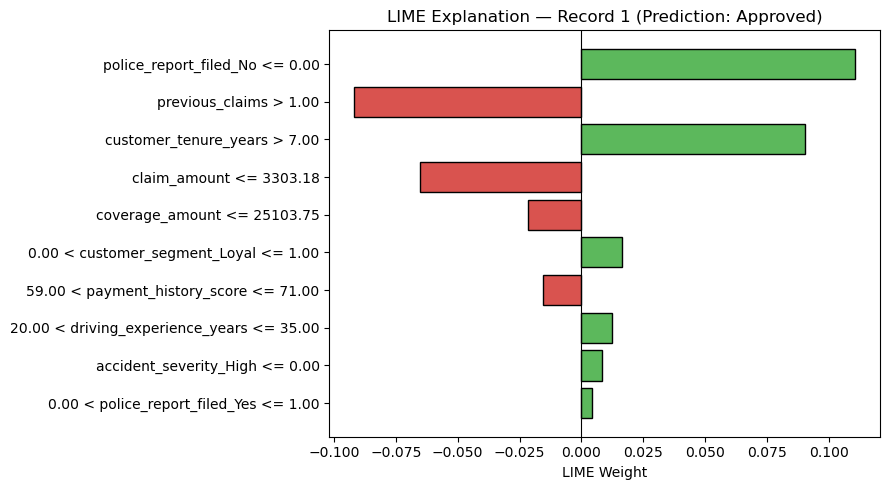

In [35]:
# LIME visualisation
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#5cb85c' if w > 0 else '#d9534f' for w in lime_df['Weight']]
bars = ax.barh(lime_df['Feature Condition'][::-1], lime_df['Weight'][::-1], color=colors[::-1], edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('LIME Weight')
ax.set_title(f'LIME Explanation — Record {lime_record_idx + 1} (Prediction: {"Approved" if prob[1] > 0.5 else "Not Approved"})')
plt.tight_layout()
plt.show()

## How LIME Helps Business Users

**LIME (Local Interpretable Model-agnostic Explanations)** provides an explanation for a *single individual prediction* in a way that is easy to interpret.

For any given claim, LIME answers the question:

> “Why did the model recommend approval or denial for this specific claimant?”

Unlike global interpretability methods, LIME focuses on **one record at a time**, making it especially useful for case-by-case review.


### How LIME Works (Conceptually)

LIME builds a simplified model around a single data point by:

- Slightly perturbing the feature values of that record
- Observing how the model’s prediction changes
- Fitting a simple interpretable model locally to approximate the decision boundary

This allows it to identify which features are most responsible for the prediction in that specific case.


## Example: Record 1 Explanation

For **Record 1**, the model outputs:

- **Not Approved probability:** 27.5%  
- **Approved probability:** 72.5%  
- **Final prediction:** Approved


### Features Supporting Approval (Positive Weights)

These features pushed the prediction toward **“Approved”**:

- `police_report_filed_No ≤ 0` **(+0.111)**
- `customer_tenure_years > 7` **(+0.091)**
- `customer_segment_Loyal` **(+0.016)**
- `driving_experience_years` (20–35 range) **(+0.012)**

These signals indicate a **long-standing, experienced, and documented claimant**, which increases model confidence in approval.


### Features Against Approval (Negative Weights)

These features pushed the prediction toward **“Not Approved”**:

- `previous_claims > 1` **(−0.092)**
- `claim_amount ≤ 3,303` **(−0.065)**
- `coverage_amount ≤ 25,104` **(−0.022)**
- `payment_history_score` (59–71 range) **(−0.016)**

These factors suggest **higher risk due to repeated claims history and relatively modest financial indicators**, which reduces approval confidence.

### Final Outcome

The positive influences outweighed the negative ones, resulting in a final prediction of:

- **72.5% probability of Approval**


## Business Interpretation

LIME is particularly valuable for operational decision-making because it translates model behaviour into **human-readable reasoning for individual cases**.

For example, a claims adjuster reviewing a borderline case can clearly see:

- Why the model recommended approval
- Which features contributed most strongly to that decision
- Whether those factors align with domain expertise and policy rules

In this case, the model approved a claimant with a history of previous claims, but the decision was justified by stronger positive signals such as:

- Long customer tenure
- Verified police report
- Experienced driver profile


## Why This Matters in Practice

LIME makes model predictions:

- **Auditable** → Decisions can be traced and reviewed
- **Defensible** → Explanations can be justified to stakeholders or regulators
- **Actionable** → Human reviewers can override or confirm based on reasoning
- **Transparent at the individual level** → No need to understand the full Decision Tree structure

This level of interpretability is especially important in **regulated industries such as insurance**, where every automated decision may need to be explained to customers, auditors, or compliance teams.

## Task 14: Fairness and Bias Reflection

In [36]:
# Attach fairness columns back to the test set
fairness_eval = fair_test.copy()
fairness_eval['Actual'] = y_test.values
fairness_eval['Predicted'] = y_pred

def fairness_report(df, group_col):
    results = []
    for group, grp in df.groupby(group_col):
        n = len(grp)
        actual_pos_rate = grp['Actual'].mean()
        pred_pos_rate = grp['Predicted'].mean()
        acc = (grp['Actual'] == grp['Predicted']).mean()
        results.append({
            'Group': group,
            'N': n,
            'Actual Positive Rate': round(actual_pos_rate, 3),
            'Predicted Positive Rate': round(pred_pos_rate, 3),
            'Accuracy': round(acc, 3)
        })
    return pd.DataFrame(results)

# Gender analysis
gender_report = fairness_report(fairness_eval, 'gender')
print("=== Fairness Analysis by Gender ===")
print(gender_report.to_string(index=False))

=== Fairness Analysis by Gender ===
 Group  N  Actual Positive Rate  Predicted Positive Rate  Accuracy
Female 31                 0.452                    0.548     0.581
  Male 45                 0.622                    0.756     0.644


In [37]:
# Region analysis
region_report = fairness_report(fairness_eval, 'region')
print("=== Fairness Analysis by Region ===")
print(region_report.to_string(index=False))

=== Fairness Analysis by Region ===
Group  N  Actual Positive Rate  Predicted Positive Rate  Accuracy
 East 19                 0.632                    0.684     0.632
North 13                 0.615                    0.769     0.692
South 17                 0.529                    0.529     0.647
 West 27                 0.481                    0.704     0.556


In [38]:
# Age group analysis
age_report = fairness_report(fairness_eval, 'age_group')
print("=== Fairness Analysis by Age Group ===")
print(age_report.to_string(index=False))

=== Fairness Analysis by Age Group ===
Group  N  Actual Positive Rate  Predicted Positive Rate  Accuracy
18-25 12                 0.417                    0.667     0.417
26-35 16                 0.562                    0.438     0.625
36-50 21                 0.667                    0.667     0.714
  51+ 27                 0.519                    0.815     0.630


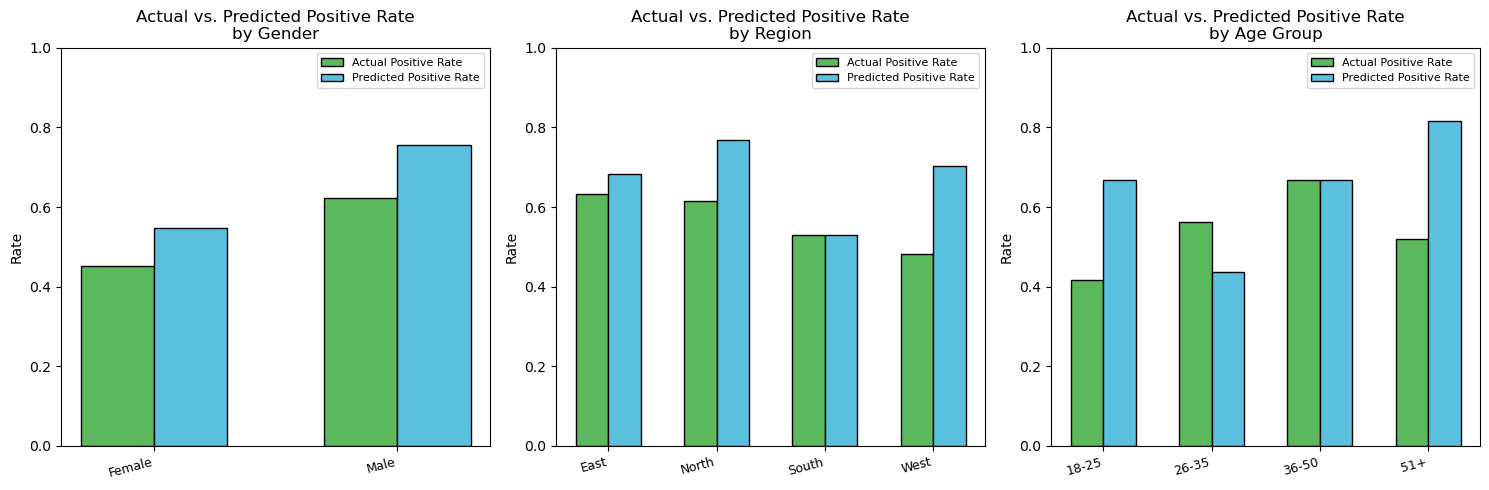

In [39]:
# Visualisation — Accuracy by group
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (report, title) in zip(axes, [
    (gender_report, 'Gender'),
    (region_report, 'Region'),
    (age_report, 'Age Group')
]):
    x = range(len(report))
    width = 0.3
    ax.bar([i - width/2 for i in x], report['Actual Positive Rate'], width, label='Actual Positive Rate', color='#5cb85c', edgecolor='black')
    ax.bar([i + width/2 for i in x], report['Predicted Positive Rate'], width, label='Predicted Positive Rate', color='#5bc0de', edgecolor='black')
    ax.set_xticks(list(x))
    ax.set_xticklabels(report['Group'], rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Actual vs. Predicted Positive Rate\nby {title}')
    ax.set_ylabel('Rate')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

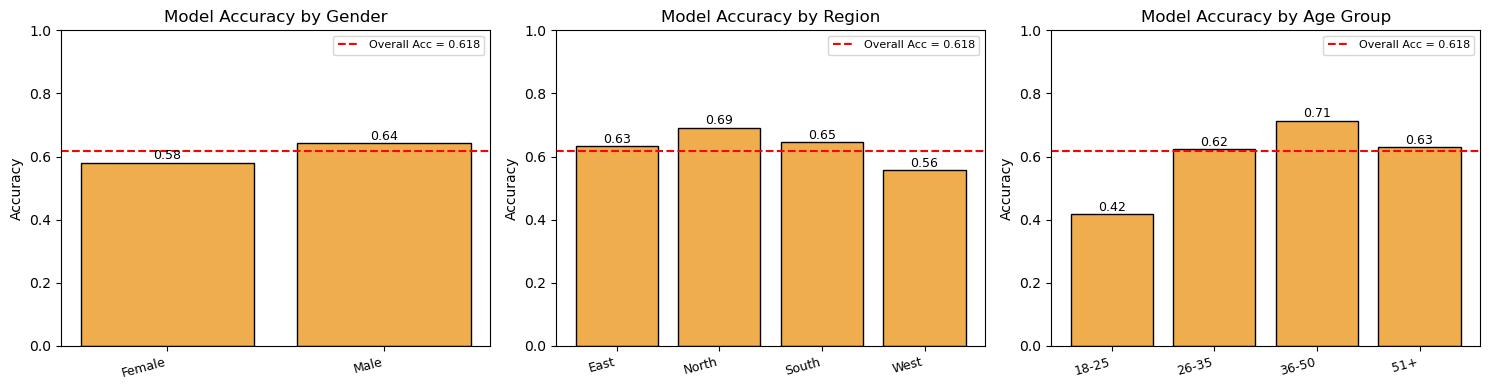

In [40]:
# Accuracy by group visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (report, title) in zip(axes, [
    (gender_report, 'Gender'),
    (region_report, 'Region'),
    (age_report, 'Age Group')
]):
    bars = ax.bar(report['Group'], report['Accuracy'], color='#f0ad4e', edgecolor='black')
    ax.set_ylim(0, 1)
    ax.axhline(acc, color='red', linestyle='--', label=f'Overall Acc = {acc:.3f}')
    ax.set_title(f'Model Accuracy by {title}')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, report['Accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.2f}', ha='center', fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

## Fairness and Bias Reflection

The fairness analysis evaluates how model performance varies across different demographic and geographic subgroups. Even though **`gender`**, **`region`**, and **`age_group`** were excluded from model training, they were retained for evaluation to detect potential **proxy bias** and unequal performance patterns.

## Gender

There is a noticeable performance gap between genders.

- **Male accuracy:** 64.4%  
- **Female accuracy:** 58.1%  
- **Gap:** ~6 percentage points

In addition, there is evidence of systematic over-approval:

- **Male predicted approval rate:** 75.6%  
- **Male actual approval rate:** 62.2%  
- **Female predicted approval rate:** 54.8%  
- **Female actual approval rate:** 45.2%

Although both groups experience some degree of over-approval, the discrepancy is larger for Male claimants, suggesting the model is more likely to incorrectly approve Male claims.

This indicates potential **indirect bias**, where gender influences predictions through correlated variables (proxy features), even though it was not explicitly included in training.

## Region (Significant Disparities)

Performance varies substantially across geographic regions.

### North
- Accuracy: 69.2% (best-performing region)
- Predicted approval: 76.9%
- Actual approval: 61.5%  
- Pattern: Strong over-approval bias

### South
- Accuracy: 64.7%
- Predicted approval: 52.9%
- Actual approval: 52.9%  
- Pattern: Well calibrated and balanced

### East
- Accuracy: 63.2%
- Moderate and relatively stable performance

### West
- Accuracy: 55.6% (lowest-performing region)
- Predicted approval: 70.4%
- Actual approval: 48.1%  
- Gap: ~22 percentage points over-approval

The **West region** is particularly concerning. With accuracy close to random performance, the model is frequently incorrect and consistently biased toward approving claims that should not be approved. In a production setting, this would create a concentrated area of financial risk.


## Age Group (Most Significant Disparities)

Age-based performance differences are the most pronounced in the entire fairness analysis.

### 18–25
- Accuracy: 41.7% (below random performance)
- Predicted approval: 66.7%
- Actual approval: 41.7%  
- Pattern: Strong over-approval bias

### 26–35
- Accuracy: 62.5%
- Predicted approval: 43.8%
- Actual approval: 56.3%  
- Pattern: Under-approval bias

### 36–50
- Accuracy: 71.4% (best-performing age group)
- Pattern: Most stable and reliable segment

### 51+
- Accuracy: 63.0%
- Predicted approval: 81.5%
- Actual approval: 51.9%  
- Gap: ~30 percentage points (largest disparity observed)

The **18–25** and **51+** groups show particularly large deviations between predicted and actual outcomes. In both cases, the model systematically over-approves claims, increasing the risk of incorrect payouts.


## Overall Fairness Concern

Across gender, region, and age group, the model demonstrates **uneven performance and systematic bias patterns**, particularly in the form of **over-approval in specific subgroups**.

Key risk areas include:

- **West region**
- **Age 18–25 group**
- **Age 51+ group**

Even though sensitive attributes were excluded from training, the model has likely learned indirect associations through correlated variables, resulting in **proxy bias effects**.


## Governance and Business Implications

These fairness gaps have important operational consequences:

- Certain groups face significantly higher error rates
- Some regions are exposed to higher financial leakage risk due to over-approval
- Younger and older claimants are treated inconsistently compared to middle-age groups

From a responsible AI perspective, this model should **not be used for fully automated decision-making**.

Instead:

- It should be used strictly as a **decision-support tool**
- All predictions should be subject to **human review**
- Special attention should be given to high-risk subgroups (West region, 18–25, 51+)

This is especially important in regulated insurance environments, where automated decisions must meet fairness, transparency, and accountability requirements.

No claimant should receive a final decision based solely on model output, particularly where subgroup disparities are as pronounced as those observed here.

## Task 15: Final Business Interpretation

In [41]:
# Summary table of all key metrics
summary = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score',
               'CV Mean Accuracy', 'CV Std Dev',
               'Training Accuracy', 'Testing Accuracy'],
    'Value': [
        f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}',
        f'{cv_scores.mean():.4f}', f'{cv_scores.std():.4f}',
        f'{train_acc:.4f}', f'{test_acc:.4f}'
    ]
}
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

           Metric  Value
         Accuracy 0.6184
        Precision 0.6275
           Recall 0.7619
         F1-Score 0.6882
 CV Mean Accuracy 0.5658
       CV Std Dev 0.0336
Training Accuracy 0.7862
 Testing Accuracy 0.6184


## Final Business Interpretation

### What the model predicts

This **Decision Tree classifier** predicts whether an insurance claim should be:

- **Approved (1)**  
- **Denied (0)**  

It makes these decisions using a combination of:

- **Customer profile features** (age, tenure, driving experience)  
- **Policy attributes** (premium, coverage, policy type)  
- **Claim details** (claim amount, severity, police report status)  
- **Behavioural signals** (payment history, previous claims)


## Overall model performance

The model shows mixed performance depending on evaluation method:

- **Test accuracy (single split):** 61.84%  
- **F1-score:** 0.688  
- **Cross-validation mean accuracy:** 56.58% (std: 0.034)  
- **Baseline accuracy (majority class):** 55.0%

While the single test split suggests moderate performance, the cross-validation result tells a more conservative and realistic story. At **56.58%**, the model is only marginally better than predicting the majority class.

The gap between test accuracy and cross-validation indicates that the **80/20 split likely produced an overly optimistic evaluation**.

### Key conclusion

This model is **not ready for production use**. It should be treated as an **early-stage prototype** that identifies useful signals in the data but does not yet provide reliable predictive performance for operational decision-making.


## Most important evaluation metric

**Precision is the most critical metric for this problem.**

In insurance claim approval:

- A **False Positive (wrongly approved claim)** leads to direct financial loss and potential fraud exposure.
- A **False Negative (wrongly denied claim)** can be corrected through appeals and review processes.

At **0.6275 precision**, the model is weak in this regard — approximately **4 in every 10 approved claims are incorrect**.


## Main error type

The dominant error is:

- **False Positives: 19 cases**
- **False Negatives: 10 cases**

This shows a clear tendency toward **over-approval**, which is the more financially damaging direction for an insurer.


## Business impact of errors

- **False Positives:**
  - Direct payout losses
  - Fraud exposure
  - Reserve mis-estimation
  - Reduced profitability

- **False Negatives:**
  - Customer complaints
  - Appeals and manual review workload
  - Potential regulatory escalation
  - Customer churn risk

While both error types matter, the **over-approval bias represents the primary financial risk**.


## Overfitting and underfitting evidence

The model shows clear signs of overfitting:

- **Training accuracy:** 78.6%  
- **Test accuracy:** 61.8%  
- **Gap:** 16.8 percentage points  

Even with `max_depth=4`, the model still fits the training data substantially better than it generalises to unseen data.

Further evidence:

- The **unconstrained depth-10 tree** overfits heavily
- **Cross-validation accuracy (56.6%) is lower than test accuracy**

### Key insight

The model is learning patterns in the training data more reliably than it generalises to new claims. This is consistent with:

- Limited dataset size (304 training records)
- Noisy real-world claim outcomes
- Feature complexity relative to sample size


## Most important features

The strongest drivers in the controlled model are:

- **payment_history_score (0.281)**
- **customer_tenure_years (0.166)**
- **police_report_filed_No (0.136)**
- **driving_experience_years (0.135)**
- **annual_premium (0.096)**

### Key interpretation

The model relies more heavily on:

- **Customer relationship history**
- **Trust and behavioural signals**
- **External validation (police reports)**

than on raw financial claim size, which is less influential than expected.


## SHAP and LIME insight

Both SHAP and LIME confirm consistent decision logic:

- **SHAP:** payment history, tenure, and police report status are the strongest global drivers of approval decisions.
- **LIME (Record 1):**
  - Positive drivers: long tenure, police report, experienced driver profile  
  - Negative drivers: multiple previous claims, lower claim amount, moderate payment score  
  - Final outcome: **72.5% probability of approval**

### Key value

These tools make individual predictions **auditable and explainable**, allowing claims teams to understand and challenge specific decisions when necessary.


## Fairness and bias concern

The model shows **systematic performance disparities across groups**, even though protected attributes were excluded from training.

Key issues:

- **Age 18–25:** 41.7% accuracy (worse than random)
- **Age 51+:** 30-point over-approval gap
- **West region:** 55.6% accuracy with 22-point over-approval bias

### Key risk

The model concentrates **over-approval errors in specific demographic and geographic groups**, which creates:

- Unequal treatment of claimants
- Increased financial exposure in certain segments
- Potential regulatory and compliance risk


## Final recommendation

This model should be considered a **baseline prototype only**, not a deployable system.

### Core limitations

- Cross-validation accuracy (~56.6%) is only slightly above baseline
- Significant overfitting is present
- Fairness disparities are material and systematic

### Recommended next steps

1. **Increase dataset size** (target ≥ 1,500 records)
2. **Test stronger models**
   - Random Forest
   - Gradient Boosting
   - Hyperparameter tuning
3. **Apply fairness mitigation techniques**
   - Reweighting
   - Post-processing corrections
   - Group-aware calibration
4. **Introduce human-in-the-loop review**
   - Mandatory review of all model-driven approvals
5. **Reframe KPI priorities**
   - Focus on **Precision ≥ 0.80** before production consideration


## Final takeaway

The model is useful as a **learning and diagnostic tool**, but not yet reliable for real-world insurance decision automation. It identifies meaningful predictors and demonstrates explainability, but its performance and fairness limitations prevent safe deployment in its current state.